In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
from shapely import wkt
from shapely.geometry import Point

In [26]:
# setup
df = pd.read_csv('../../data/processed/neighborhood_crime_counts.csv')

# geopandas
neighborhoods_df = pd.read_csv('../../data/raw/denver_statistical_neighborhoods_20250409.csv')
neighborhoods_df = neighborhoods_df.drop(columns=['TYPOLOGY', 'NOTES'])
neighborhoods_df["the_geom"] = neighborhoods_df["the_geom"].apply(wkt.loads)
gdf_neighborhoods = gpd.GeoDataFrame(neighborhoods_df, geometry="the_geom", crs="EPSG:4326")

In [10]:
gdf_neighborhoods.columns

Index(['the_geom', 'NBHD_ID', 'NBHD_NAME'], dtype='object')

In [11]:
gdf_neighborhoods = gdf_neighborhoods.rename(columns={"NBHD_NAME": "neighborhood"})

In [13]:
gdf_merged = gdf_neighborhoods.merge(df, on='neighborhood', how='left')

## Highest Crime Rates

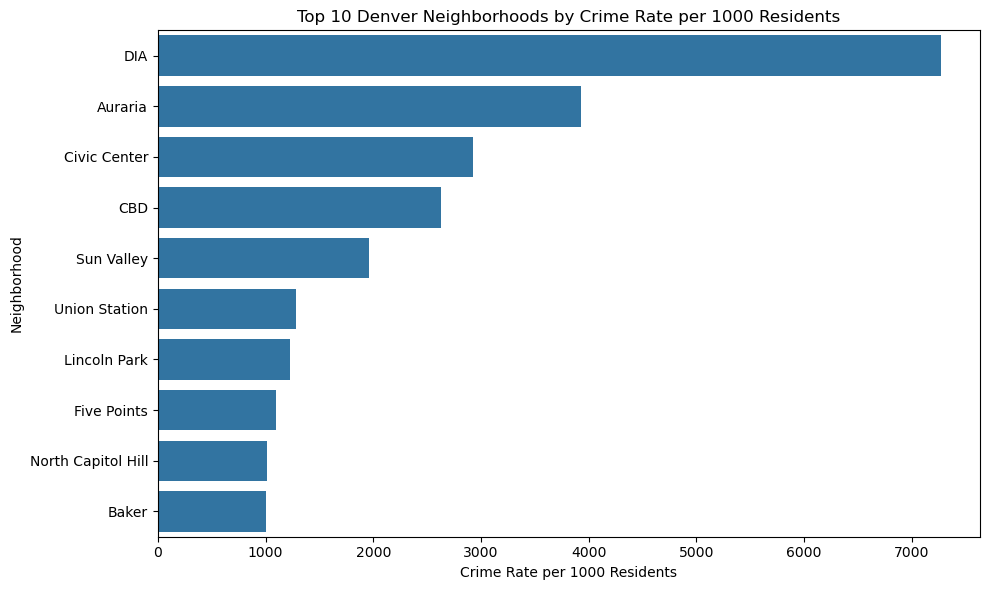

In [5]:
top_crime = df.sort_values('crime_per1000', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_crime,
    x='crime_per1000',
    y='neighborhood'
)
plt.title('Top 10 Denver Neighborhoods by Crime Rate per 1000 Residents')
plt.xlabel('Crime Rate per 1000 Residents')
plt.ylabel('Neighborhood')
plt.tight_layout()
plt.show()

## Lowest Crime Rates

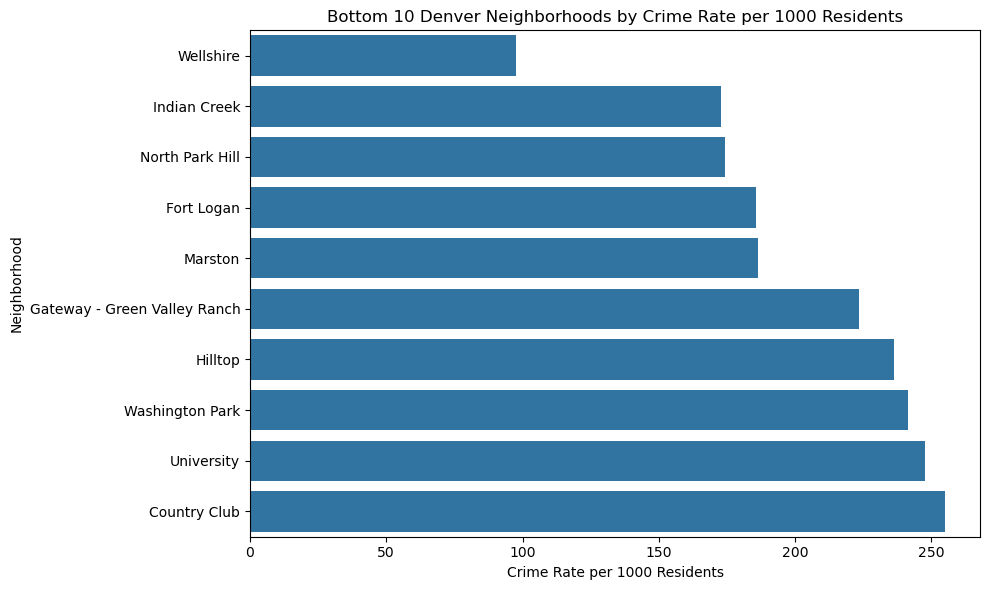

In [7]:
bottom_crime = df.sort_values('crime_per1000', ascending=True).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=bottom_crime,
    x='crime_per1000',
    y='neighborhood'
)
plt.title('Bottom 10 Denver Neighborhoods by Crime Rate per 1000 Residents')
plt.xlabel('Crime Rate per 1000 Residents')
plt.ylabel('Neighborhood')
plt.tight_layout()
plt.show()

## Choropleth

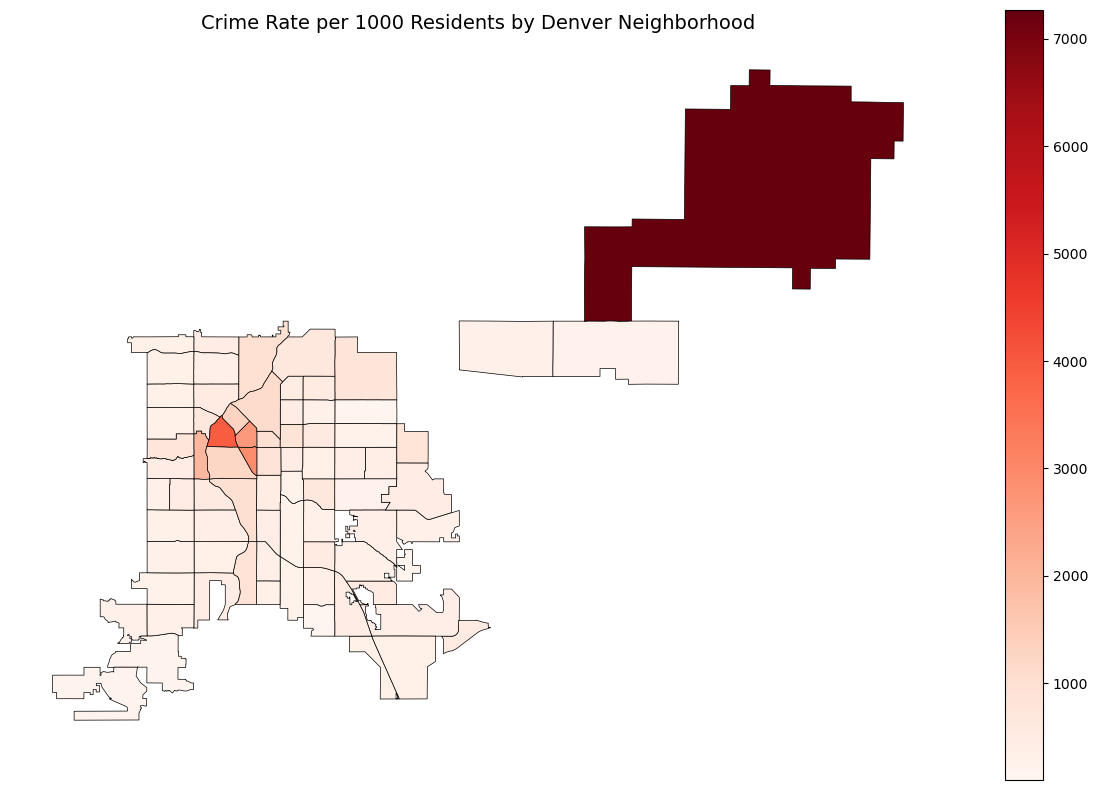

In [15]:
fig, ax = plt.subplots(figsize=(12, 8))
gdf_merged.plot(
    column='crime_per1000',
    cmap='Reds',
    linewidth=0.5,
    edgecolor='black',
    legend=True,
    ax=ax
)

ax.set_title('Crime Rate per 1000 Residents by Denver Neighborhood', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

## Compared with Other Features

In [16]:
list(df.columns)

['neighborhood',
 'avgsocioeconscore',
 'avgAccessToCareScore',
 'avgMobidityScore',
 'mortalityscore',
 'avgBuiltEnvScore',
 'avgOverallEquityScore',
 'Percent Hispanic',
 'Percent White',
 'Percent Black',
 'Percent Native American',
 'Percent Asian',
 'Percent Hawaiian/Pacific Islander',
 'Percent Other Race',
 'Percent Two or More Races',
 'Median Household Income',
 'Per Capita Income',
 'Median Home Value',
 'Percent Living in Poverty',
 'Percent Families in Poverty',
 'population_density',
 'percent_less_hs',
 'percent_at_hs',
 'percent_some_college',
 'percent_bachelors',
 'crime_per1000',
 'theft_mv_per1000',
 'auto_theft_per1000',
 'disorder_per1000',
 'larceny_per1000',
 'other_per1000',
 'burglary_per1000',
 'drug_alcohol_per1000',
 'crime_against_persons_per1000',
 'assult_per1000',
 'robbery_per1000',
 'white_collar_per1000',
 'arson_per1000',
 'murder_per1000',
 'program_count_per1000']

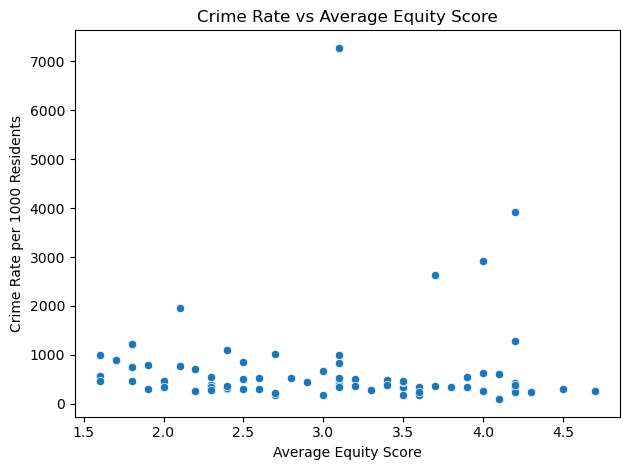

In [18]:
# Equity Scores
sns.scatterplot(data=df, x='avgOverallEquityScore', y='crime_per1000')
plt.title('Crime Rate vs Average Equity Score')
plt.xlabel('Average Equity Score')
plt.ylabel('Crime Rate per 1000 Residents')
plt.tight_layout()
plt.show()

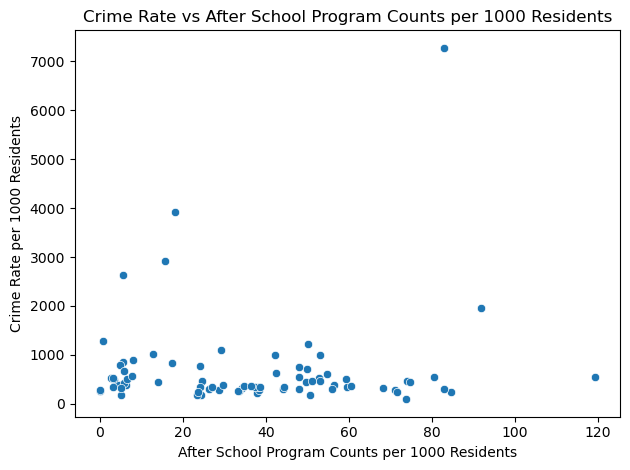

In [19]:
# After School Program Counts
sns.scatterplot(data=df, x='program_count_per1000', y='crime_per1000')
plt.title('Crime Rate vs After School Program Counts per 1000 Residents')
plt.xlabel('After School Program Counts per 1000 Residents')
plt.ylabel('Crime Rate per 1000 Residents')
plt.tight_layout()
plt.show()

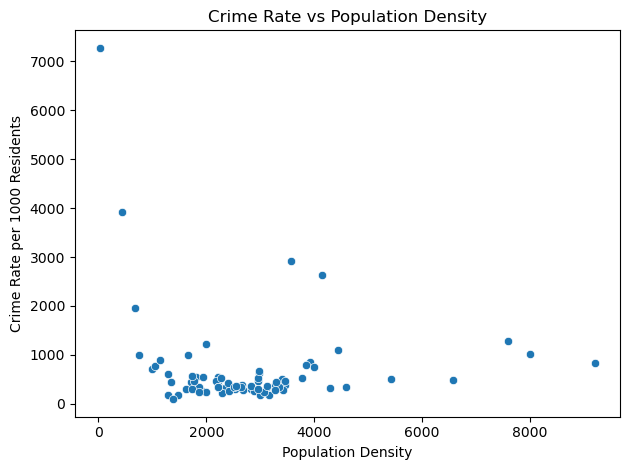

In [20]:
# Demographics - population density
sns.scatterplot(data=df, x='population_density', y='crime_per1000')
plt.title('Crime Rate vs Population Density')
plt.xlabel('Population Density')
plt.ylabel('Crime Rate per 1000 Residents')
plt.tight_layout()
plt.show()

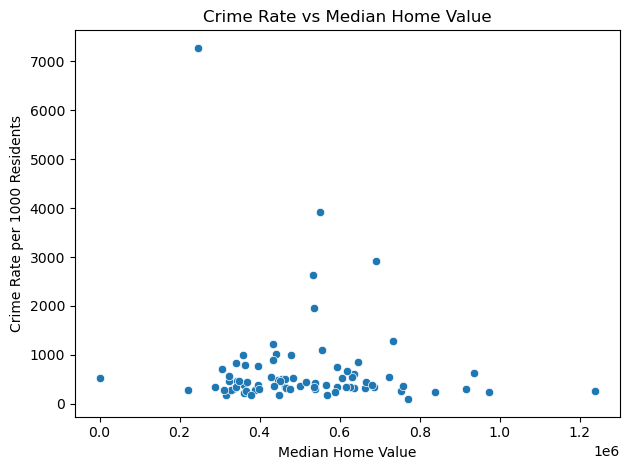

In [21]:
# Demographics - Home Price
sns.scatterplot(data=df, x='Median Home Value', y='crime_per1000')
plt.title('Crime Rate vs Median Home Value')
plt.xlabel('Median Home Value')
plt.ylabel('Crime Rate per 1000 Residents')
plt.tight_layout()
plt.show()

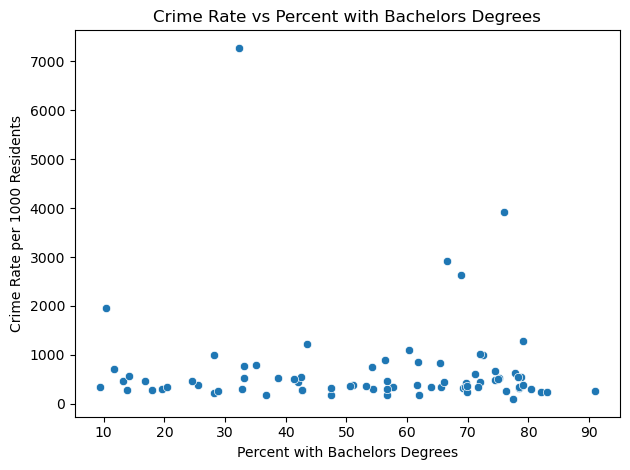

In [22]:
# Demographics - Higher Education
sns.scatterplot(data=df, x='percent_bachelors', y='crime_per1000')
plt.title('Crime Rate vs Percent with Bachelors Degrees')
plt.xlabel('Percent with Bachelors Degrees')
plt.ylabel('Crime Rate per 1000 Residents')
plt.tight_layout()
plt.show()

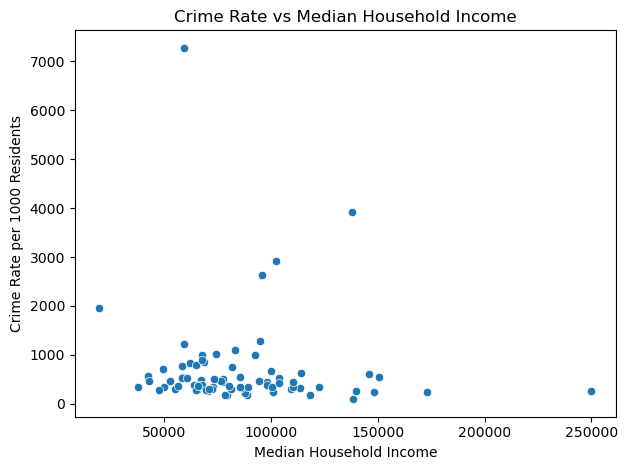

In [23]:
# Demographics - Income
sns.scatterplot(data=df, x='Median Household Income', y='crime_per1000')
plt.title('Crime Rate vs Median Household Income')
plt.xlabel('Median Household Income')
plt.ylabel('Crime Rate per 1000 Residents')
plt.tight_layout()
plt.show()

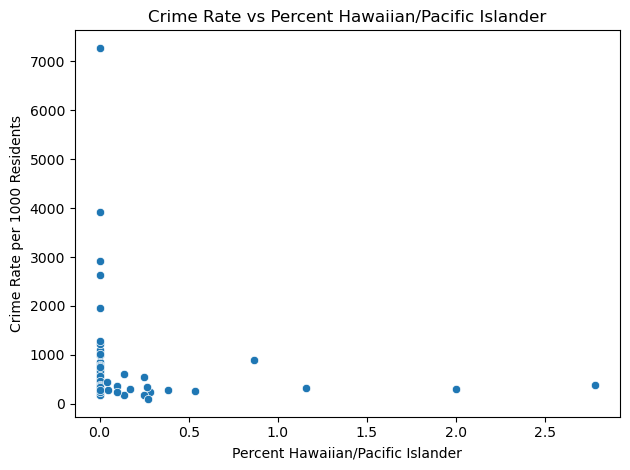

In [24]:
# Demographics - Percent Hawaiian/Pacific Islander
sns.scatterplot(data=df, x='Percent Hawaiian/Pacific Islander', y='crime_per1000')
plt.title('Crime Rate vs Percent Hawaiian/Pacific Islander')
plt.xlabel('Percent Hawaiian/Pacific Islander')
plt.ylabel('Crime Rate per 1000 Residents')
plt.tight_layout()
plt.show()

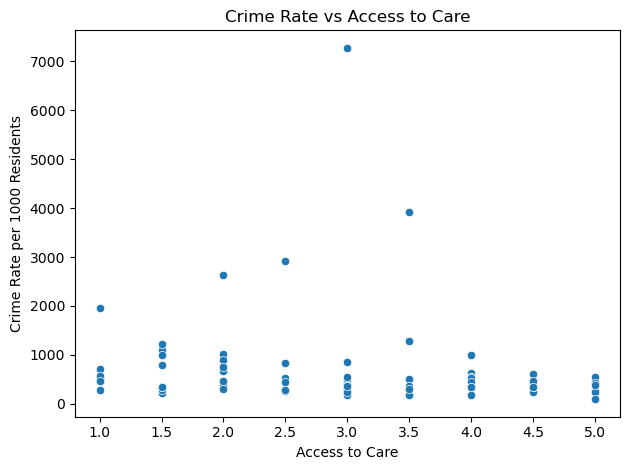

In [27]:
# avgAccessToCareScore
sns.scatterplot(data=df, x='avgAccessToCareScore', y='crime_per1000')
plt.title('Crime Rate vs Access to Care')
plt.xlabel('Access to Care')
plt.ylabel('Crime Rate per 1000 Residents')
plt.tight_layout()
plt.show()